In [8]:
import os
import numpy as np
import tifffile
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import label, binary_fill_holes, binary_opening

def load_and_fill_mask(mask_path):
    """
    Load a 2D binary mask, fill internal hollow structures (0s fully surrounded by 1s),
    and return the filled mask. Returns None if the mask is empty.
    """
    mask = np.array(Image.open(mask_path))
    if mask.ndim == 3:
        mask = mask[:, :, 0]  # Convert RGB to grayscale

    binary_mask = mask > 0
    if not binary_mask.any():
        return None

    # Invert mask to find holes (0s inside the structure become 1)
    inverse = ~binary_mask

    # Label all connected regions in the inverse mask
    labeled, num_features = label(inverse)

    # Identify labels touching the border — these are NOT holes
    border_labels = np.unique(np.concatenate([
        labeled[0, :], labeled[-1, :], labeled[:, 0], labeled[:, -1]
    ]))

    # Create a mask of the true holes: regions in inverse mask NOT touching border
    hole_mask = np.isin(labeled, border_labels, invert=True)

    # Fill the holes in the original binary mask
    filled_mask = binary_mask | hole_mask
    filled_mask = binary_opening(filled_mask,structure=np.ones((20,20)))

    return filled_mask.astype(bool)



def plot_signal_mask_overlay(signal_path, mask_path, cmap='jet', alpha=0.5):
    """
    Overlay a mask (PNG) over a grayscale signal image (TIF).
    """
    signal = tifffile.imread(signal_path).astype(np.float32)
    mask = np.array(Image.open(mask_path))

    if mask.ndim == 3:
        mask = mask[:, :, 0]  # convert RGB to grayscale
    if signal.shape != mask.shape:
        raise ValueError(f"Shape mismatch: {signal.shape} vs {mask.shape}")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(signal, cmap='gray')
    im = ax.imshow(mask, cmap=cmap, alpha=alpha)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mask value')
    ax.set_title("Central Slice Overlay")
    ax.axis("off")
    plt.tight_layout()
    plt.show()



def compute_masked_mean_std_percentile(signal_dir, mask_dir, label="", lower_p=0.01, upper_p=99.99):
    signal_files = sorted([f for f in os.listdir(signal_dir) if f.lower().endswith('.tif')])
    mask_files = sorted([f for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
    
    if len(signal_files) != len(mask_files):
        raise ValueError(f"[{label}] Mismatched files: {len(signal_files)} signals vs {len(mask_files)} masks")

    print(f"[{label}] Collecting all masked values for percentile-based mean/std...")

    all_masked_values = []

    for idx in tqdm(range(len(signal_files)), desc=f"[{label}] Collecting", unit="slice"):
        sig_path = os.path.join(signal_dir, signal_files[idx])
        mask_path = os.path.join(mask_dir, mask_files[idx])

        sig = tifffile.imread(sig_path).astype(np.float32)
        mask = load_and_fill_mask(mask_path)
        

        if mask is None:
            continue  # skip empty mask slice

        if sig.shape != mask.shape:
            
            raise ValueError(f"Shape mismatch at slice {idx}: {sig.shape} vs {mask.shape}")

        masked_values = sig[mask]
        all_masked_values.append(masked_values)
        
        # Plot overlay at halfway slice
        if idx == len(signal_files) // 2:
            print(f"[{label}] Visualizing central slice at index {idx}")
            plot_signal_mask_overlay(sig_path, mask_path, cmap='jet', alpha=0.4)
            
    all_masked_values = np.concatenate(all_masked_values)

    # Compute percentiles
    p_min, p_max = np.percentile(all_masked_values, [lower_p, upper_p])
    print(f"[{label}] Using percentile range: {p_min:.2f} - {p_max:.2f}")
    print(f"[{label}] For   min - max  range: {np.min(all_masked_values):.2f} - {np.max(all_masked_values):.2f}")

    # Filter values within percentile range
    filtered = all_masked_values[(all_masked_values >= p_min) & (all_masked_values <= p_max)]

    # Compute stats
    if filtered.size == 0:
        raise ValueError(f"[{label}] No masked values within percentile range.")

    mean = filtered.mean()
    std = filtered.std()

    print(f"[{label}] Final (masked, clipped): Mean = {mean:.4f}, Std = {std:.4f}")
    return mean, std, (p_min, p_max)

Processing data
E:/thierry/heart/LADAF_2024_56\ROI\segmentation_SAM2_data\masks
E:/thierry/heart/LADAF_2024_56\data
[data] Collecting all masked values for percentile-based mean/std...


[data] Collecting:  50%|█████     | 1365/2730 [19:09<19:22,  1.17slice/s]

[data] Visualizing central slice at index 1365


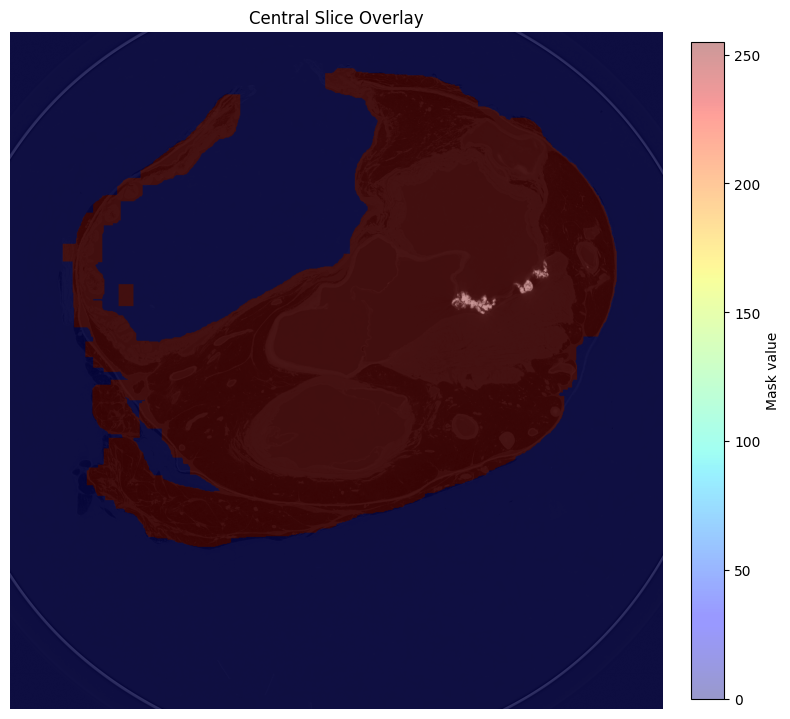

[data] Collecting: 100%|██████████| 2730/2730 [37:48<00:00,  1.20slice/s]


[data] Using percentile range: 1812.00 - 58356.00
[data] For   min - max  range: 44.00 - 65535.00
[data] Final (masked, clipped): Mean = 6482.3853, Std = 2243.9011
[OK] data → Mean: 6482.3853, Std: 2243.9011


In [7]:
base_mask_root = r"E:/thierry/heart/LADAF_2024_28"
base_signal_root = r"E:/thierry/heart/new_data/LADAF_2024_28"

results = []

for kidney_dir in os.listdir(base_mask_root):
    kidney_path = os.path.join(base_mask_root, kidney_dir)
    if not os.path.isdir(kidney_path):
        continue
    if kidney_dir != 'data':
        continue
    print(f'Processing {kidney_dir}')

    mask_dir = os.path.join(base_mask_root,"ROI", "segmentation_SAM2_data", "masks")
    print(mask_dir)
    if not os.path.isdir(mask_dir):
        continue

    # Construct signal directory from mask folder structure
    signal_dir = os.path.join(base_signal_root, kidney_dir)
    print(signal_dir)
    if not os.path.isdir(signal_dir):
        print(f"[WARNING] Skipping: No matching signal dir for {mask_dir}")
        continue

    try:
        mean, std, (p_min, p_max) = compute_masked_mean_std_percentile(signal_dir, mask_dir,label=kidney_dir)
        results.append((kidney_dir, mean, std, p_min, p_max))
        print(f"[OK] {kidney_dir} → Mean: {mean:.4f}, Std: {std:.4f}")
    except Exception as e:
        print(f"[ERROR] {kidney_dir}: {e}")


df = pd.DataFrame(results, columns=["Kidney", "MeanIntensity", "StdIntensity", "P01", "P9999"])
df.to_csv("masked_intensity_stats.csv", index=False)